In [1]:
import glob
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

from spot_intensity_analysis_utils import load_trackmate_spots
from spot_intensity_analysis_utils import load_trackmate_tracks
from spot_intensity_analysis_utils import load_meanint_ROIs
from spot_intensity_analysis_utils import remove_shorttracks_3
from spot_intensity_analysis_utils import remove_shorttracks_spotsfile
from spot_intensity_analysis_utils import split_table_by_track
from spot_intensity_analysis_utils import split_table_by_ROI_and_track
from spot_intensity_analysis_utils import first_10_frames
from spot_intensity_analysis_utils import meanint_tracks_ch2
from spot_intensity_analysis_utils import meanint_tracks_per_ROI_ch2

import sys
sys.path.append("..")

pd.set_option('display.max_columns', None) # Displays all columns of df

In [2]:
# Reads in spots file of one ROI

B2_D21_pos4_ROI1_spots = pd.read_csv('/Volumes/gchao/bamfaile/Analysis/TUBB2B-KI/Batch20230223/Tracking_output/D21/Spots_files/100tp_561-100-50ms-1000g_4_conf561_merged_ROI1_spots.csv')

B2_D21_pos4_ROI1_spots.head(10)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,Radius,Visibility,Custom Integer Spot Feature,Custom Double Spot Feature,Has max quality,Manual spot color,Mean intensity ch1,Median intensity ch1,Min intensity ch1,Max intensity ch1,Sum intensity ch1,Std intensity ch1,Mean intensity ch2,Median intensity ch2,Min intensity ch2,Max intensity ch2,Sum intensity ch2,Std intensity ch2,Contrast ch1,Signal/Noise ratio ch1,Contrast ch2,Signal/Noise ratio ch2
1,Label,Spot ID,Track ID,Quality,X,Y,Z,T,Frame,R,Visibility,Integer Spot Feature,Double Spot Feature,Max Quality,Spot color,Mean ch1,Median ch1,Min ch1,Max ch1,Sum ch1,Std ch1,Mean ch2,Median ch2,Min ch2,Max ch2,Sum ch2,Std ch2,Ctrst ch1,SNR ch1,Ctrst ch2,SNR ch2
2,NaN,NaN,NaN,(quality),(µm),(µm),(µm),(sec),NaN,(µm),NaN,NaN,NaN,NaN,NaN,(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),(counts),NaN,NaN,NaN,NaN
3,ID2273,2273,0,1375.3369140625,31.763234133708867,93.16058217901809,0.0,1.1,22,0.25,1,NaN,NaN,1,NaN,5343.190476190476,5257.0,4385.0,6537.0,112207.0,699.7394242893291,5412.9047619047615,5536.0,3308.0,9010.0,113671.0,1429.472206961783,0.09713858069465685,1.352149074082752,0.10380792681531954,0.712232315821107
4,ID2210,2210,0,1553.3736572265625,32.163374190468275,93.58136670016349,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,6240.047619047619,6285.0,4666.0,7559.0,131041.0,813.5928020939268,6163.571428571428,5683.0,4136.0,9936.0,129435.0,1659.188041525992,0.09394157704179946,1.3172691464482371,0.09711186233802176,0.6576399566168509
5,ID2275,2275,0,1079.6805419921875,31.8490478773457,93.14991229140745,0.0,1.2000000000000002,24,0.25,1,NaN,NaN,0,NaN,4992.428571428572,5095.0,3949.0,5973.0,104841.0,559.171581129493,5280.523809523809,5280.0,3265.0,7967.0,110891.0,1124.8644637931993,0.07815899849689097,1.2944728273213015,0.11322782538658106,0.9549396307314915
6,ID2244,2244,0,1643.6729736328125,31.98578290413947,93.28510761357815,0.0,0.65,13,0.25,1,NaN,NaN,0,NaN,5868.238095238095,5803.0,4843.0,7259.0,123233.0,750.6291297812725,5906.619047619048,5721.0,4010.0,10106.0,124039.0,1452.0280808645016,0.10501676808449291,1.4859427873748488,0.09985384796266174,0.7386246017812003
7,ID2215,2215,0,3986.6376953125,32.558324946803545,93.73491786306582,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,7969.238095238095,7899.0,5817.0,11813.0,167354.0,1902.453755147859,7700.761904761905,7212.0,4265.0,13268.0,161716.0,2523.6299630643534,0.18270791399308772,1.2942332279070303,0.17063541587419404,0.8895810701571525
8,ID2280,2280,0,1563.6197509765625,31.709194421491055,93.19360048098072,0.0,1.25,25,0.25,1,NaN,NaN,0,NaN,5272.428571428572,5167.0,3757.0,6774.0,110721.0,883.2056143066897,5368.571428571428,5543.0,1771.0,8286.0,112740.0,1600.67884259862,0.1026230879541109,1.1112118803716915,0.12397382517253659,0.7398749619752231
9,ID2250,2250,0,1649.4718017578125,32.00910482986898,93.43627428586616,0.0,0.7000000000000001,14,0.25,1,NaN,NaN,0,NaN,6073.809523809524,6096.0,4917.0,7513.0,127550.0,803.0821638567014,6130.380952380952,6124.0,3238.0,10000.0,128738.0,1555.7572585782937,0.10174972494047195,1.3969519765320022,0.11062305871703866,0.7849727838281837


In [3]:
# Removes first three rows from spots file

B2_D21_pos4_ROI1_clean = B2_D21_pos4_ROI1_spots.drop(labels = [0,1,2], axis=0, inplace=False).reset_index(drop=True)

B2_D21_pos4_ROI1_clean.head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,ID2273,2273,0,1375.3369140625,31.763234133708867,93.16058217901809,0.0,1.1,22,0.25,1,NaN,NaN,1,NaN,5343.190476190476,5257.0,4385.0,6537.0,112207.0,699.7394242893291,5412.9047619047615,5536.0,3308.0,9010.0,113671.0,1429.472206961783,0.09713858069465685,1.352149074082752,0.10380792681531954,0.712232315821107
1,ID2210,2210,0,1553.3736572265625,32.163374190468275,93.58136670016349,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,6240.047619047619,6285.0,4666.0,7559.0,131041.0,813.5928020939268,6163.571428571428,5683.0,4136.0,9936.0,129435.0,1659.188041525992,0.09394157704179946,1.3172691464482371,0.09711186233802176,0.6576399566168509
2,ID2275,2275,0,1079.6805419921875,31.8490478773457,93.14991229140745,0.0,1.2000000000000002,24,0.25,1,NaN,NaN,0,NaN,4992.428571428572,5095.0,3949.0,5973.0,104841.0,559.171581129493,5280.523809523809,5280.0,3265.0,7967.0,110891.0,1124.8644637931993,0.07815899849689097,1.2944728273213015,0.11322782538658106,0.9549396307314915
3,ID2244,2244,0,1643.6729736328125,31.98578290413947,93.28510761357815,0.0,0.65,13,0.25,1,NaN,NaN,0,NaN,5868.238095238095,5803.0,4843.0,7259.0,123233.0,750.6291297812725,5906.619047619048,5721.0,4010.0,10106.0,124039.0,1452.0280808645016,0.10501676808449291,1.4859427873748488,0.09985384796266174,0.7386246017812003
4,ID2215,2215,0,3986.6376953125,32.558324946803545,93.73491786306582,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,7969.238095238095,7899.0,5817.0,11813.0,167354.0,1902.453755147859,7700.761904761905,7212.0,4265.0,13268.0,161716.0,2523.6299630643534,0.18270791399308772,1.2942332279070303,0.17063541587419404,0.8895810701571525


In [18]:
# Adds column "ROI_ID" as unique identifier of each ROI

In [4]:
# Splits tables into seperate dfs by TRACK_ID and sorts it by frame

B2_D21_pos4_ROI1_singletracks = [j for i,j in split_table_by_track(B2_D21_pos4_ROI1_clean)]

B2_D21_pos4_ROI1_singletracks_sorted = []


for df in B2_D21_pos4_ROI1_singletracks:
    df["FRAME"] = df["FRAME"].astype(int) # Is necessary for correct sorting
    df = df.sort_values(by="FRAME").reset_index(drop=True)
    B2_D21_pos4_ROI1_singletracks_sorted.append(df)

B2_D21_pos4_ROI1_singletracks_sorted[15].head(20)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,ID2440,2440,15,2277.968017578125,30.437906353252064,95.93765393354492,0.0,3.75,75,0.25,1,NaN,NaN,0,NaN,5217.190476190476,5090.0,3645.0,7393.0,109561.0,1054.3838778664826,5255.333333333333,4649.0,3506.0,7909.0,110362.0,1372.645450702159,0.15549954122151088,1.3317639862170672,0.16799577155874615,1.1013591603369328
1,ID2444,2444,15,2032.7396240234375,30.453944513741146,95.82845937456857,0.0,3.8000000000000003,76,0.25,1,NaN,NaN,0,NaN,5299.666666666667,5213.0,3920.0,7015.0,111293.0,905.4209702306067,5489.523809523809,5391.0,3338.0,7475.0,115280.0,1260.7072467090693,0.14977098397965669,1.524910448102658,0.15975013724072382,1.1995745047154978
2,ID2453,2453,15,988.0654296875,30.421041105087685,95.90711937049043,0.0,3.85,77,0.25,1,NaN,NaN,0,NaN,4358.476190476191,4507.0,3594.0,5228.0,91528.0,482.9520285750562,4655.857142857143,4628.0,2897.0,6881.0,97773.0,1017.0446050058122,0.08281821544812187,1.3804827814349807,0.12557155034972955,1.0214280740243202
3,ID2486,2486,15,948.251708984375,30.528356452450836,95.73547535824741,0.0,3.95,79,0.25,1,NaN,NaN,0,NaN,4574.619047619048,4586.0,3937.0,5281.0,96067.0,399.3284958765748,4872.761904761905,5012.0,2555.0,8032.0,102328.0,1405.7412601457604,0.08470473484741563,1.789166585512169,0.12424913952321644,0.7661796639508806
4,ID2464,2464,15,1415.0765380859375,30.591495331010286,95.46580473560432,0.0,4.0,80,0.25,1,NaN,NaN,0,NaN,5069.428571428572,5130.0,4229.0,6288.0,106458.0,655.7021863184971,5309.761904761905,5285.0,3084.0,7932.0,111505.0,1111.9996360054217,0.10405682571516778,1.4573421250089567,0.12645809605451355,1.0720918535533925
5,ID2471,2471,15,1874.5859375,30.64789181088111,95.57705642646508,0.0,4.05,81,0.25,1,NaN,NaN,1,NaN,5186.380952380952,5022.0,4070.0,6725.0,108914.0,798.868104019085,5316.0952380952385,5211.0,3330.0,7601.0,111638.0,1283.387038455738,0.14359825905769866,1.6304031913082737,0.14877887814902804,1.072926414417223
6,ID2474,2474,15,3370.684814453125,30.732705134448448,95.53280096161609,0.0,4.1000000000000005,82,0.25,1,NaN,NaN,1,NaN,6576.428571428572,6244.0,4578.0,9611.0,138105.0,1464.2476420137602,6589.333333333333,6040.0,4081.0,10575.0,138376.0,1725.3129088177986,0.20407908688330326,1.5224711048254338,0.20175972895591204,1.28239093889449
7,ID2467,2467,15,3407.4521484375,30.663822161789074,95.51188133356675,0.0,4.15,83,0.25,1,NaN,NaN,1,NaN,6791.9047619047615,6495.0,4663.0,9582.0,142630.0,1412.8389471118746,7017.761904761905,6675.0,4861.0,10886.0,147373.0,1578.3221440745835,0.21288377067463835,1.6875330759293272,0.22842685811801836,1.6536014277655722
8,ID2476,2476,15,4262.36865234375,30.683206742089315,95.46477137949368,0.0,4.2,84,0.25,1,NaN,NaN,1,NaN,7471.523809523809,7083.0,4818.0,11077.0,156902.0,1882.6681762606927,7330.809523809524,7066.0,3939.0,12312.0,153947.0,2087.939166236594,0.24162016369826061,1.544577898721009,0.21777143666865012,1.2557385387724358
9,ID2479,2479,15,3021.1689453125,30.50770628167817,95.50058191913303,0.0,4.25,85,0.25,1,NaN,NaN,1,NaN,6835.476190476191,6878.0,4867.0,9152.0,143545.0,1343.616709446843,6967.857142857143,6790.0,3961.0,10201.0,146325.0,1673.7087048143796,0.1930984381256229,1.646743122153105,0.19407271400491982,1.353265667411177


In [5]:
# Concatenates sorted tracks into one df

B2_D21_pos4_ROI1_alltracks_sorted = pd.concat(B2_D21_pos4_ROI1_singletracks_sorted).reset_index(drop=True)
B2_D21_pos4_ROI1_alltracks_sorted.head()

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,ID2228,2228,0,4173.595703125,32.51722620866835,93.72419960014665,0.0,0.25,5,0.25,1,NaN,NaN,1,NaN,8049.523809523809,7690.0,4987.0,12208.0,169040.0,2186.1047920684778,7812.0,8125.0,3577.0,13441.0,164052.0,2711.7256867168553,0.19000940017641488,1.1758553613803706,0.17730560172498988,0.8677202278590654
1,ID2215,2215,0,3986.6376953125,32.558324946803545,93.73491786306582,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,7969.238095238095,7899.0,5817.0,11813.0,167354.0,1902.453755147859,7700.761904761905,7212.0,4265.0,13268.0,161716.0,2523.6299630643534,0.18270791399308772,1.2942332279070303,0.17063541587419404,0.8895810701571525
2,ID2205,2205,0,3845.408447265625,32.49195592349267,93.88329037130359,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,0,NaN,7848.809523809524,7602.0,5392.0,11413.0,164825.0,1902.4121430186367,7513.952380952381,6947.0,4056.0,12562.0,157793.0,2558.59001163122,0.1834598952437295,1.279136147298183,0.16065155024567832,0.812981754357293
3,ID2189,2189,0,1306.96240234375,31.978008853870545,93.80614600683901,0.0,0.4,8,0.25,1,NaN,NaN,0,NaN,6214.476190476191,6310.0,5125.0,7206.0,130504.0,574.1068384061994,6481.666666666667,6315.0,4563.0,8529.0,136115.0,1115.373808789382,0.08585773651523955,1.7117814237741178,0.10212661365346899,1.0769702045255651
4,ID2210,2210,0,1553.3736572265625,32.163374190468275,93.58136670016349,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,6240.047619047619,6285.0,4666.0,7559.0,131041.0,813.5928020939268,6163.571428571428,5683.0,4136.0,9936.0,129435.0,1659.188041525992,0.09394157704179946,1.3172691464482371,0.09711186233802176,0.6576399566168509


In [6]:
B2_D21_pos4_ROI1_singletrack0 = B2_D21_pos4_ROI1_singletracks_sorted[0]
B2_D21_pos4_ROI1_singletrack0.head(50)

,LABEL,ID,TRACK_ID,QUALITY,POSITION_X,POSITION_Y,POSITION_Z,POSITION_T,FRAME,RADIUS,VISIBILITY,MANUAL_INTEGER_SPOT_FEATURE,MANUAL_DOUBLE_SPOT_FEATURE,HAS_MAX_QUALITY_IN_FRAME,MANUAL_SPOT_COLOR,MEAN_INTENSITY_CH1,MEDIAN_INTENSITY_CH1,MIN_INTENSITY_CH1,MAX_INTENSITY_CH1,TOTAL_INTENSITY_CH1,STD_INTENSITY_CH1,MEAN_INTENSITY_CH2,MEDIAN_INTENSITY_CH2,MIN_INTENSITY_CH2,MAX_INTENSITY_CH2,TOTAL_INTENSITY_CH2,STD_INTENSITY_CH2,CONTRAST_CH1,SNR_CH1,CONTRAST_CH2,SNR_CH2
0,ID2228,2228,0,4173.595703125,32.51722620866835,93.72419960014665,0.0,0.25,5,0.25,1,NaN,NaN,1,NaN,8049.523809523809,7690.0,4987.0,12208.0,169040.0,2186.1047920684778,7812.0,8125.0,3577.0,13441.0,164052.0,2711.7256867168553,0.19000940017641488,1.1758553613803706,0.17730560172498988,0.8677202278590654
1,ID2215,2215,0,3986.6376953125,32.558324946803545,93.73491786306582,0.0,0.30000000000000004,6,0.25,1,NaN,NaN,1,NaN,7969.238095238095,7899.0,5817.0,11813.0,167354.0,1902.453755147859,7700.761904761905,7212.0,4265.0,13268.0,161716.0,2523.6299630643534,0.18270791399308772,1.2942332279070303,0.17063541587419404,0.8895810701571525
2,ID2205,2205,0,3845.408447265625,32.49195592349267,93.88329037130359,0.0,0.35000000000000003,7,0.25,1,NaN,NaN,0,NaN,7848.809523809524,7602.0,5392.0,11413.0,164825.0,1902.4121430186367,7513.952380952381,6947.0,4056.0,12562.0,157793.0,2558.59001163122,0.1834598952437295,1.279136147298183,0.16065155024567832,0.812981754357293
3,ID2189,2189,0,1306.96240234375,31.978008853870545,93.80614600683901,0.0,0.4,8,0.25,1,NaN,NaN,0,NaN,6214.476190476191,6310.0,5125.0,7206.0,130504.0,574.1068384061994,6481.666666666667,6315.0,4563.0,8529.0,136115.0,1115.373808789382,0.08585773651523955,1.7117814237741178,0.10212661365346899,1.0769702045255651
4,ID2210,2210,0,1553.3736572265625,32.163374190468275,93.58136670016349,0.0,0.45,9,0.25,1,NaN,NaN,0,NaN,6240.047619047619,6285.0,4666.0,7559.0,131041.0,813.5928020939268,6163.571428571428,5683.0,4136.0,9936.0,129435.0,1659.188041525992,0.09394157704179946,1.3172691464482371,0.09711186233802176,0.6576399566168509
5,ID2198,2198,0,1260.9219970703125,32.156099464909694,93.45129668849198,0.0,0.5,10,0.25,1,NaN,NaN,0,NaN,5596.190476190476,5577.0,4366.0,6744.0,117520.0,754.2549051247609,6140.619047619048,6125.0,4401.0,8489.0,128953.0,1116.1933289618996,0.07906191269226129,1.087239678832736,0.13553775913049912,1.3132924560224775
6,ID2192,2192,0,1512.1143798828125,32.056245782064714,93.12554801575828,0.0,0.55,11,0.25,1,NaN,NaN,0,NaN,5292.761904761905,5161.0,4390.0,6788.0,111148.0,680.5732072864686,5436.285714285715,5095.0,3232.0,7681.0,114162.0,1313.968612367021,0.09664034717892453,1.3706663998104978,0.12447766240518943,0.9159839622470306
7,ID2221,2221,0,1707.1431884765625,32.06983040539109,93.11390067129163,0.0,0.6000000000000001,12,0.25,1,NaN,NaN,0,NaN,5747.619047619048,5715.0,4554.0,7326.0,120700.0,806.4444479435937,5976.428571428572,6097.0,3626.0,9119.0,125505.0,1390.4716311895245,0.1085764275963891,1.3960900226791517,0.1299459678456091,0.9885866187544586
8,ID2244,2244,0,1643.6729736328125,31.98578290413947,93.28510761357815,0.0,0.65,13,0.25,1,NaN,NaN,0,NaN,5868.238095238095,5803.0,4843.0,7259.0,123233.0,750.6291297812725,5906.619047619048,5721.0,4010.0,10106.0,124039.0,1452.0280808645016,0.10501676808449291,1.4859427873748488,0.09985384796266174,0.7386246017812003
9,ID2250,2250,0,1649.4718017578125,32.00910482986898,93.43627428586616,0.0,0.7000000000000001,14,0.25,1,NaN,NaN,0,NaN,6073.809523809524,6096.0,4917.0,7513.0,127550.0,803.0821638567014,6130.380952380952,6124.0,3238.0,10000.0,128738.0,1555.7572585782937,0.10174972494047195,1.3969519765320022,0.11062305871703866,0.7849727838281837


In [15]:
# Defines function to calculate time-averaged MSD(tamsd) for a single track in a given ROI

def calculate_single_tamsd(
    single_traj: pd.DataFrame, min_length: int = 10, min_points: int = 1
):
    """Calculates time-averaged MSDs of one track in a given ROI.
    
    Inputs: 
        df containing coordintes of one trajectory in an ROI, sorted by frame.
        min_length: minimum length of trajectory.
        min_points: minimum number of points to consider to calculate tamsd.
        
    Return:
        results: pd.DataFrame containing lags and time-averaged MSDs of a given track.
    """
    
    # Calculates pair-wise differences between all timepoints in the trajectory and stores it in a matrix
    tvalues = single_traj["FRAME"].values
    tvalues = tvalues[:, None] - tvalues
  
    # List of lags
    lags = np.arange(len(single_traj)) + 1
    
    final_lags = []
    tamsd = []
    
    # Loop over lags
    for lag in lags:
        # Find indices of pairs of timepoints with lag equal to the selected lag
        x,y = np.where(tvalues == lag)
        
        single_traj["POSITION_X"] = single_traj["POSITION_X"].astype(float)
        single_traj["POSITION_Y"] = single_traj["POSITION_Y"].astype(float)
        
        if len(single_traj) < min_length:
            continue
        
        if len(x) < min_points:
            continue
        
        tmp_tamsd = np.mean(
            np.sum(
                np.square(
                single_traj.iloc[x][["POSITION_X","POSITION_Y"]].values
                -single_traj.iloc[y][["POSITION_X","POSITION_Y"]].values
                ),
                axis = 1,
            )
        )
        
        final_lags.append(lag)
        tamsd.append(tmp_tamsd)
    
    df = pd.DataFrame({"lags": final_lags, "tamsd": tamsd})
    
    return df    

In [16]:
# Calculates time-averaged MSD(tamsd) for a single track in a given ROI

tamsd_singletrack0 = calculate_single_tamsd(B2_D21_pos4_ROI1_singletrack0)
print(tamsd_singletrack0)

    lags     tamsd
0      1  0.043977
1      2  0.080604
2      3  0.110375
3      4  0.130803
4      5  0.161406
5      6  0.173468
6      7  0.179347
7      8  0.180991
8      9  0.169250
9     10  0.165547
10    11  0.147870
11    12  0.182363
12    13  0.211514
13    14  0.262463
14    15  0.347088
15    16  0.462050
16    17  0.531300
17    18  0.588604
18    19  0.656540
19    20  0.688979
20    21  0.748399
21    22  0.673554
22    23  0.719423


To get correct amount of lags, +1 needs to be added to the np.arange(len(single_traj)), otherwise the first lag would be 0. 
Specific example where one track contains 24 time points: The tvalues, meaning the differences between time points, range from +/- 1 to +/- 23, excluding (!) the value 24. Therefore when finding values where tvalues == lags, the value 24, which is an artifact of the len(single_traj) calculation, is excluded and the remaining values range from 1 to 23, which corresponds exactly to the amount of lags present.

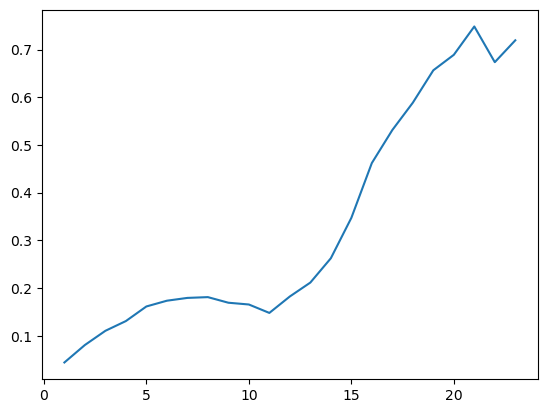

In [17]:
fig, ax = plt.subplots()
ax.plot(tamsd_singletrack0["lags"],tamsd_singletrack0["tamsd"])

In [ ]:
# Calculates time-averaged MSD (tamsd) for a all tracks in a given ROI

def calculate_all_tamsd(
    all_traj: pd.DataFrame, min_points: int = 1, min_length: int = 10, radial: bool = False
):
    """Calculates time-averaged MSDs of all tracks in a given ROI.
    
    Inputs: 
        df containing coordintes of every trajectory in an ROI, sorted by "FRAME".
        min_points: minimum number of points to consider time-averaged MSD.
        min_length: minimum length of trajectory accepted.
        
    Return:
        results: pd.DataFrame containing all time-averaged MSDs of a give ROI.
    """
    
    # Output results
    results = pd.DataFrame()
    
    # Loop for all tracks
    for track_id in all_traj["TRACK_ID"].unique():
        
        # Extract single trajectories and sort by frame
        single_traj = all_traj[all_traj["TRACK_ID"] == track_id].copy().sort_values(by="FRAME")
        
        # Filter out short tracks
        if len(single_traj) < min_length:
            continue
            
        df_tmp = calculate_single_tamsd(
            single_traj, min_points = min_points
        )
        df_tmp["ROI_ID"] = secrets.token_hex(8)
        results = pd.concat([results, df_tmp])
        
    return results

## Further steps

Here I need to calculate MSDs of all tracks of one ROI, then I need to write this into a loop to do it for all ROIs. Functions will end up in another utils file once they have been completed. Another measure to potentially calculate is the instantenous diffusion coefficient (formula is slightly different). This could be more informative with short and few tracks - MSD normally performs well at high n but is less robust with fewer points to look at. We will have to see which one performs better in which situation - both could be useful.

To be able to derive diffusion coefficients from the MSD, I will need to do curve fitting. Since I want to pick up the heterogeneity of each track, it would probably be good to do curve fitting for all tracks individually and then plot distributions of the diffusion coefficients. 